# Задание 2
- Добавить к сигналу из ЛР5 белый гауссовский шум с нулевым математическим ожиданием и произвольно выбранной дисперсией.

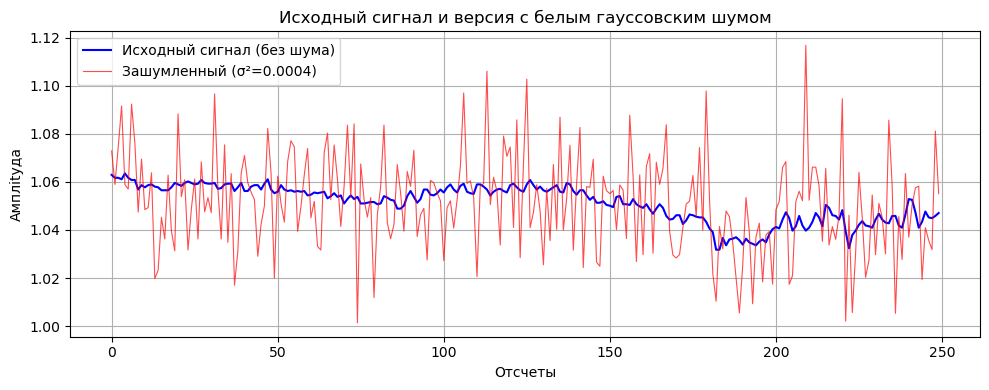

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pywt

# 1. Загрузка исходного сигнала
df = pd.read_csv("../05_lab/data/lab5_data6.txt", sep=';', usecols=['отсчеты', 'Канал0', 'Канал1'])
signal_orig = df['Канал0'].values
N = len(signal_orig)

# 2. Добавление белого гауссовского шума (μ=0, σ²=0.0004)
np.random.seed(42)  # фиксация для воспроизводимости
noise_variance = 0.0004
noise_std = np.sqrt(noise_variance)
noise = np.random.normal(loc=0, scale=noise_std, size=N)
signal_noisy = signal_orig + noise

# 3. График
plt.figure(figsize=(10, 4))
plt.plot(signal_orig, 'b', linewidth=1.5, label='Исходный сигнал (без шума)')
plt.plot(signal_noisy, 'r', linewidth=0.8, alpha=0.7, label=f'Зашумленный (σ²={noise_variance})')
plt.title('Исходный сигнал и версия с белым гауссовским шумом')
plt.xlabel('Отсчеты')
plt.ylabel('Амплitуда')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

- Вычисление прямого дискретного вейвлет-преобразования с пошаговым выводом графиков коэффициентов.

🔹 Прямое ДВП (вейвлет: db4)
   Уровень 1: A1 len=128, D1 len=128
   Уровень 2: A2 len=67, D2 len=67
   Уровень 3: A3 len=37, D3 len=37
   Уровень 4: A4 len=22, D4 len=22


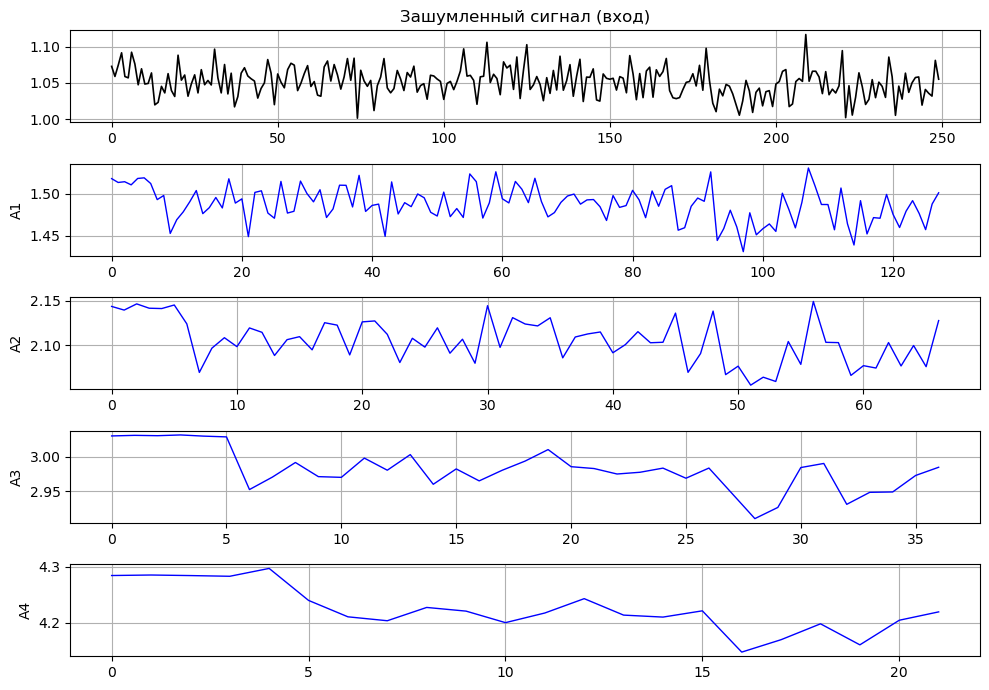

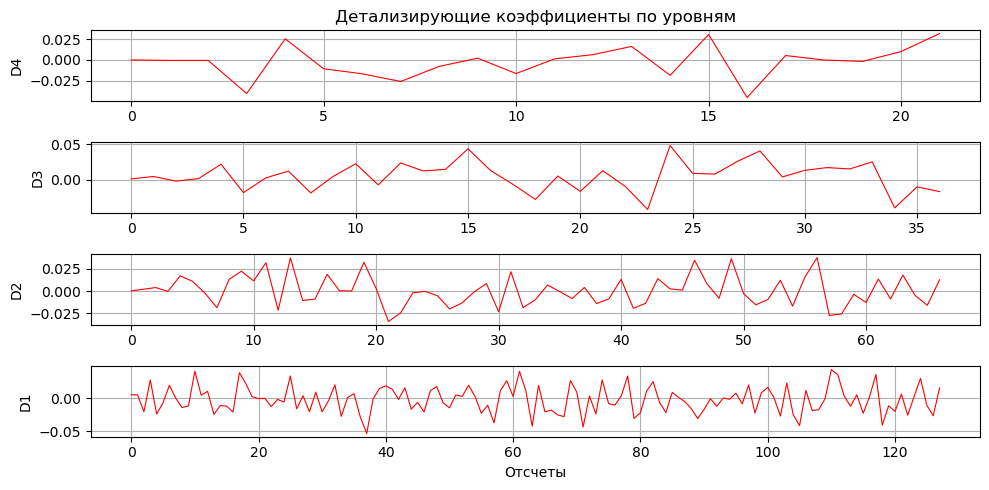

In [12]:
# Параметры первого вейвлета
wavelet_1 = 'db4'   # Добеши 4-го порядка
max_level = 4

# Пошаговое вычисление ДВП
current_sig = signal_noisy.copy()
approx_list = []
detail_list = []

print(f"🔹 Прямое ДВП (вейвлет: {wavelet_1})")
for lvl in range(1, max_level + 1):
    cA, cD = pywt.dwt(current_sig, wavelet_1, mode='symmetric')
    approx_list.append(cA)
    detail_list.append(cD)
    current_sig = cA
    print(f"   Уровень {lvl}: A{lvl} len={len(cA)}, D{lvl} len={len(cD)}")

# График аппроксимирующих коэффициентов
fig, axes = plt.subplots(max_level + 1, 1, figsize=(10, 7), sharex=False)
axes[0].plot(signal_noisy, 'k', linewidth=1.2)
axes[0].set_title('Зашумленный сигнал (вход)')
axes[0].grid(True)
for i in range(max_level):
    axes[i+1].plot(approx_list[i], 'b', linewidth=1)
    axes[i+1].set_ylabel(f'A{i+1}')
    axes[i+1].grid(True)
plt.tight_layout()
plt.show()

# График детализирующих коэффициентов
fig, axes = plt.subplots(max_level, 1, figsize=(10, 5), sharex=False)
for i in range(max_level):
    idx = max_level - 1 - i  # вывод от грубых к мелким: D4, D3, D2, D1
    axes[i].plot(detail_list[idx], 'r', linewidth=0.8)
    axes[i].set_ylabel(f'D{idx+1}')
    axes[i].grid(True)
axes[-1].set_xlabel('Отсчеты')
axes[0].set_title('Детализирующие коэффициенты по уровням')
plt.tight_layout()
plt.show()

- Вычисление обратного дискретного вейвлет-преобразования.

✅ Обратное ДВП выполнено.
📊 MSE между ИСХОДНЫМ (чистым) и восстановленным сигналом: 3.718130e-04


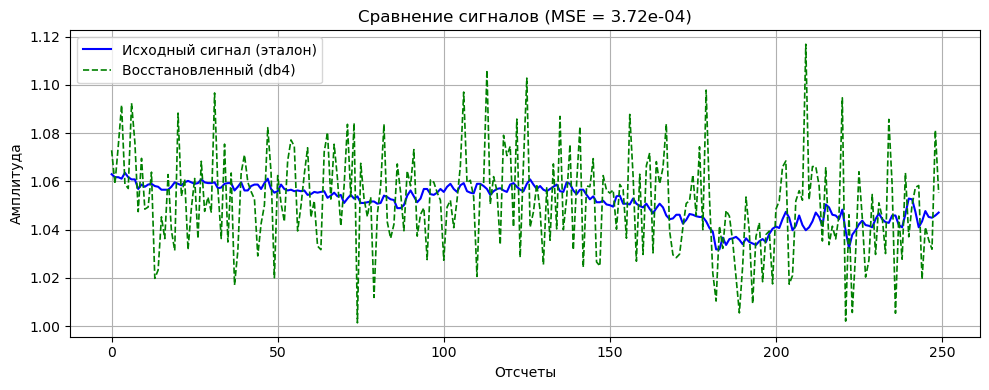

In [13]:
# Сборка коэффициентов для восстановления: [A_n, D_n, D_{n-1}, ..., D_1]
coeffs_rec = [approx_list[-1]] + detail_list[::-1]

# Обратное ДВП
signal_rec = pywt.waverec(coeffs_rec, wavelet_1)
signal_rec = signal_rec[:N]  # обрезка до исходной длины (учет boundary effects)

# Вычисление MSE по формуле: MSE = (1/N) * Σ(f(k) - f̂(k))²
mse = np.mean((signal_orig - signal_rec) ** 2)
print(f"✅ Обратное ДВП выполнено.")
print(f"📊 MSE между ИСХОДНЫМ (чистым) и восстановленным сигналом: {mse:.6e}")

# График сравнения
plt.figure(figsize=(10, 4))
plt.plot(signal_orig, 'b', linewidth=1.5, label='Исходный сигнал (эталон)')
plt.plot(signal_rec, 'g', linewidth=1.2, linestyle='--', label=f'Восстановленный ({wavelet_1})')
plt.title(f'Сравнение сигналов (MSE = {mse:.2e})')
plt.xlabel('Отсчеты')
plt.ylabel('Амплитуда')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

- Сравнение исходного сигнала (без шума) с сигналом, прошедшим через фильтр. 
$$MSE = \frac{1}{N} \sum_{k=0}^{N-1}(f(k) - \hat{f}(k))^2$$
где $f(k)$ - эталонный сигнал, $\hat{f}(k)$ - восстановленный сигнал.

🔹 Прямое ДВП (вейвлет: sym5)


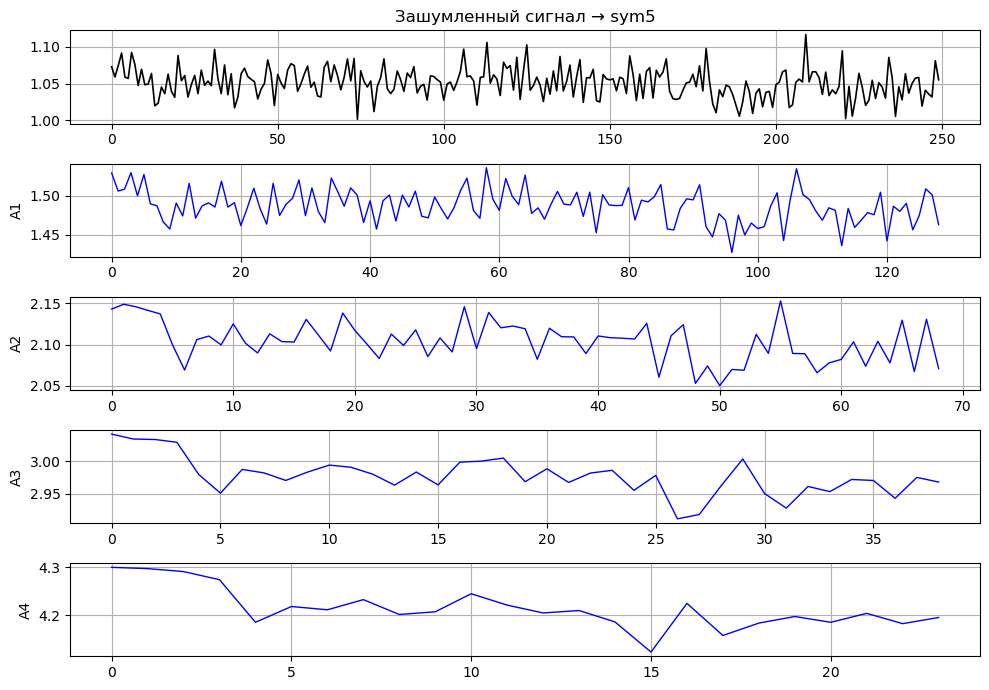

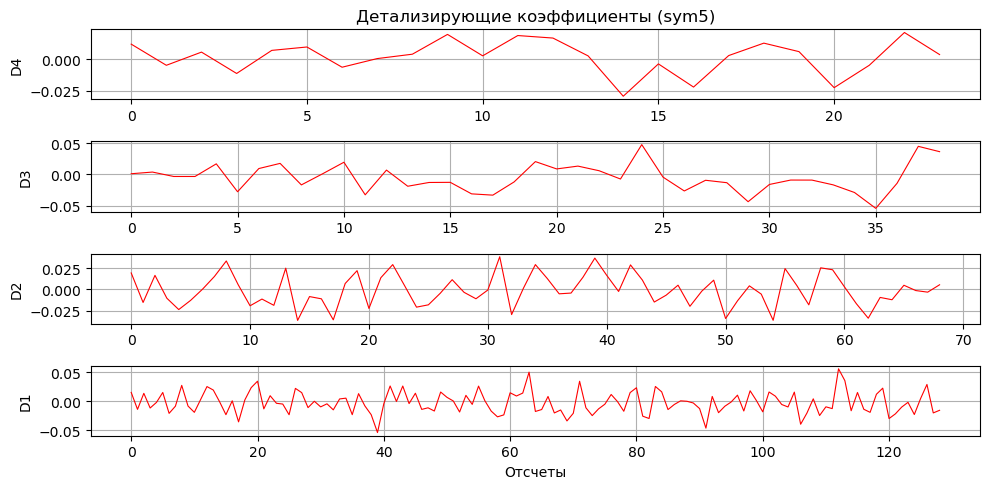

In [14]:
# Параметры второго вейвлета
wavelet_2 = 'sym5'  # Симлеты 5-го порядка

current_sig_2 = signal_noisy.copy()
approx_list_2 = []
detail_list_2 = []

print(f"🔹 Прямое ДВП (вейвлет: {wavelet_2})")
for lvl in range(1, max_level + 1):
    cA, cD = pywt.dwt(current_sig_2, wavelet_2, mode='symmetric')
    approx_list_2.append(cA)
    detail_list_2.append(cD)
    current_sig_2 = cA

# Графики коэффициентов (аналогично Блоку 2)
fig, axes = plt.subplots(max_level + 1, 1, figsize=(10, 7))
axes[0].plot(signal_noisy, 'k', linewidth=1.2)
axes[0].set_title(f'Зашумленный сигнал → {wavelet_2}')
axes[0].grid(True)
for i in range(max_level):
    axes[i+1].plot(approx_list_2[i], 'b', linewidth=1)
    axes[i+1].set_ylabel(f'A{i+1}')
    axes[i+1].grid(True)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(max_level, 1, figsize=(10, 5))
for i in range(max_level):
    idx = max_level - 1 - i
    axes[i].plot(detail_list_2[idx], 'r', linewidth=0.8)
    axes[i].set_ylabel(f'D{idx+1}')
    axes[i].grid(True)
axes[-1].set_xlabel('Отсчеты')
axes[0].set_title(f'Детализирующие коэффициенты ({wavelet_2})')
plt.tight_layout()
plt.show()

- Поменять вейвлет на произвольный неуказанный в вариантах и повторить все пункты выше.

✅ Восстановление завершено (sym5). MSE: 3.718130e-04


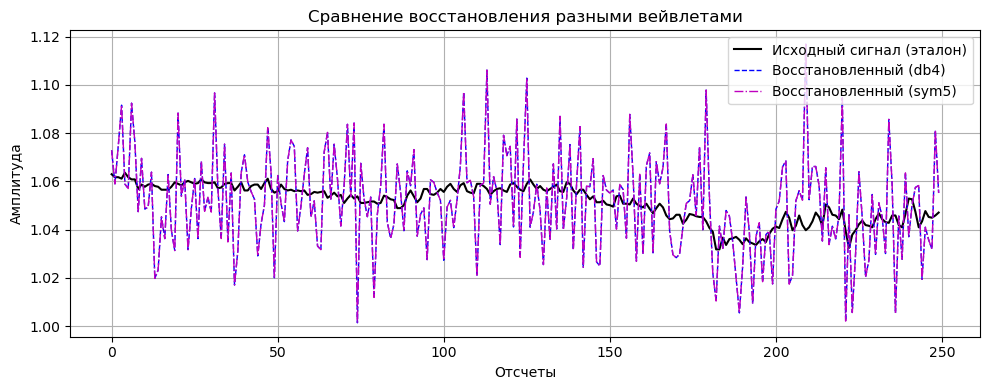


📊 Итоговые MSE:
   db4: 3.718130e-04
   sym5: 3.718130e-04


In [15]:
coeffs_rec_2 = [approx_list_2[-1]] + detail_list_2[::-1]
signal_rec_2 = pywt.waverec(coeffs_rec_2, wavelet_2)[:N]

mse_2 = np.mean((signal_orig - signal_rec_2) ** 2)
print(f"✅ Восстановление завершено ({wavelet_2}). MSE: {mse_2:.6e}")

# Сводный график сравнения обоих вейвлетов
plt.figure(figsize=(10, 4))
plt.plot(signal_orig, 'k', linewidth=1.5, label='Исходный сигнал (эталон)')
plt.plot(signal_rec, 'b', linewidth=1, linestyle='--', label=f'Восстановленный ({wavelet_1})')
plt.plot(signal_rec_2, 'm', linewidth=1, linestyle='-.', label=f'Восстановленный ({wavelet_2})')
plt.title(f'Сравнение восстановления разными вейвлетами')
plt.xlabel('Отсчеты')
plt.ylabel('Амплитуда')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"\n📊 Итоговые MSE:")
print(f"   {wavelet_1}: {mse:.6e}")
print(f"   {wavelet_2}: {mse_2:.6e}")